# 08 — Logistic Regression: Baseline Cancellation Model
**Hotel Booking Demand Dataset**

This notebook trains a **Logistic Regression** classifier as the baseline model
for cancellation prediction — the simplest interpretable benchmark against which
all subsequent models will be compared.

**Pipeline:**
- Feature scaling (StandardScaler) → Logistic Regression (lbfgs, max_iter=2000)
- Trained on SMOTE-balanced training set
- Evaluated on original (unbalanced) test set — real-world conditions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, warnings

from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

COLORS = {"0": "#2ca02c", "1": "#d62728"}


In [2]:
base = "../data/cleaned/"

with open(base + "X_train_sm.pkl", "rb") as f: X_train_sm = pickle.load(f)
with open(base + "y_train_sm.pkl", "rb") as f: y_train_sm = pickle.load(f)
with open(base + "X_test.pkl",     "rb") as f: X_test     = pickle.load(f)
with open(base + "y_test.pkl",     "rb") as f: y_test     = pickle.load(f)

print(f"Training set (SMOTE) : {X_train_sm.shape[0]:>7,} samples x {X_train_sm.shape[1]} features")
print(f"Test set (original)  : {X_test.shape[0]:>7,} samples x {X_test.shape[1]} features")
print()
print(f"Train class balance  : {pd.Series(y_train_sm).value_counts(normalize=True).to_dict()}")
print(f"Test  class balance  : {pd.Series(y_test).value_counts(normalize=True).round(4).to_dict()}")


Training set (SMOTE) :  98,814 samples x 34 features
Test set (original)  :  17,120 samples x 34 features

Train class balance  : {0: 0.5, 1: 0.5}
Test  class balance  : {0: 0.7215, 1: 0.2785}


---
## 1 — Train Logistic Regression Model

In [3]:
# Pipeline: scale features first (required for LR convergence on mixed-scale data)
model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                    max_iter    = 2000,
                    random_state= 42,
                    solver      = "lbfgs",
                    C           = 1.0,    # default regularisation strength
               ))
])

model_lr.fit(X_train_sm, y_train_sm)

print("✅ Logistic Regression trained successfully")
print(f"   Solver        : lbfgs")
print(f"   max_iter      : 2000")
print(f"   C (1/lambda)  : 1.0")
print(f"   Training rows : {X_train_sm.shape[0]:,}")
print(f"   Features      : {X_train_sm.shape[1]}")


✅ Logistic Regression trained successfully
   Solver        : lbfgs
   max_iter      : 2000
   C (1/lambda)  : 1.0
   Training rows : 98,814
   Features      : 34


---
## 2 — Predictions on Test Set

In [4]:
# Hard labels (0 / 1)
y_pred = model_lr.predict(X_test)

# Probability scores for class 1 (cancelled) — needed for ROC
y_prob = model_lr.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(y_pred):,} test samples")
print(f"Predicted cancellations : {y_pred.sum():,}  ({y_pred.mean()*100:.2f}%)")
print(f"Actual  cancellations   : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")


Predictions generated for 17,120 test samples
Predicted cancellations : 5,789  (33.81%)
Actual  cancellations   : 4,768  (27.85%)


---
## 3 — Evaluation Metrics

In [5]:
acc     = accuracy_score(y_test, y_pred)
auc     = roc_auc_score(y_test, y_prob)
cm      = confusion_matrix(y_test, y_pred)
report  = classification_report(y_test, y_pred,
              target_names=["Not Cancelled (0)", "Cancelled (1)"])

tn, fp, fn, tp = cm.ravel()

print("=" * 55)
print("  LOGISTIC REGRESSION — EVALUATION SUMMARY")
print("=" * 55)
print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC Score   : {auc:.4f}")
print()
print(f"  Confusion Matrix breakdown:")
print(f"    True  Negatives (TN) : {tn:>5,}  — correct 'will stay' predictions")
print(f"    False Positives (FP) : {fp:>5,}  — predicted cancel, but stayed")
print(f"    False Negatives (FN) : {fn:>5,}  — predicted stay, but cancelled ⚠")
print(f"    True  Positives (TP) : {tp:>5,}  — correct 'will cancel' predictions")
print()
print(f"  Class-specific rates:")
print(f"    Recall  class 1 (cancelled) : {tp/(tp+fn):.4f}  ({tp/(tp+fn)*100:.2f}%)")
print(f"    Recall  class 0 (not cancel): {tn/(tn+fp):.4f}  ({tn/(tn+fp)*100:.2f}%)")
print(f"    Precision class 1           : {tp/(tp+fp):.4f}  ({tp/(tp+fp)*100:.2f}%)")
print()
print(report)
print("=" * 55)


  LOGISTIC REGRESSION — EVALUATION SUMMARY
  Accuracy        : 0.7385  (73.85%)
  ROC-AUC Score   : 0.7852

  Confusion Matrix breakdown:
    True  Negatives (TN) : 9,603  — correct 'will stay' predictions
    False Positives (FP) : 2,749  — predicted cancel, but stayed
    False Negatives (FN) : 1,728  — predicted stay, but cancelled ⚠
    True  Positives (TP) : 3,040  — correct 'will cancel' predictions

  Class-specific rates:
    Recall  class 1 (cancelled) : 0.6376  (63.76%)
    Recall  class 0 (not cancel): 0.7774  (77.74%)
    Precision class 1           : 0.5251  (52.51%)

                   precision    recall  f1-score   support

Not Cancelled (0)       0.85      0.78      0.81     12352
    Cancelled (1)       0.53      0.64      0.58      4768

         accuracy                           0.74     17120
        macro avg       0.69      0.71      0.69     17120
     weighted avg       0.76      0.74      0.75     17120



### Confusion Matrix

C:\Users\sneha\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\sneha\AppData\Local\Temp\ipykernel_11632\749959713.py:37: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig("../visuals/lr_confusion_matrix.png",


C:\Users\sneha\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


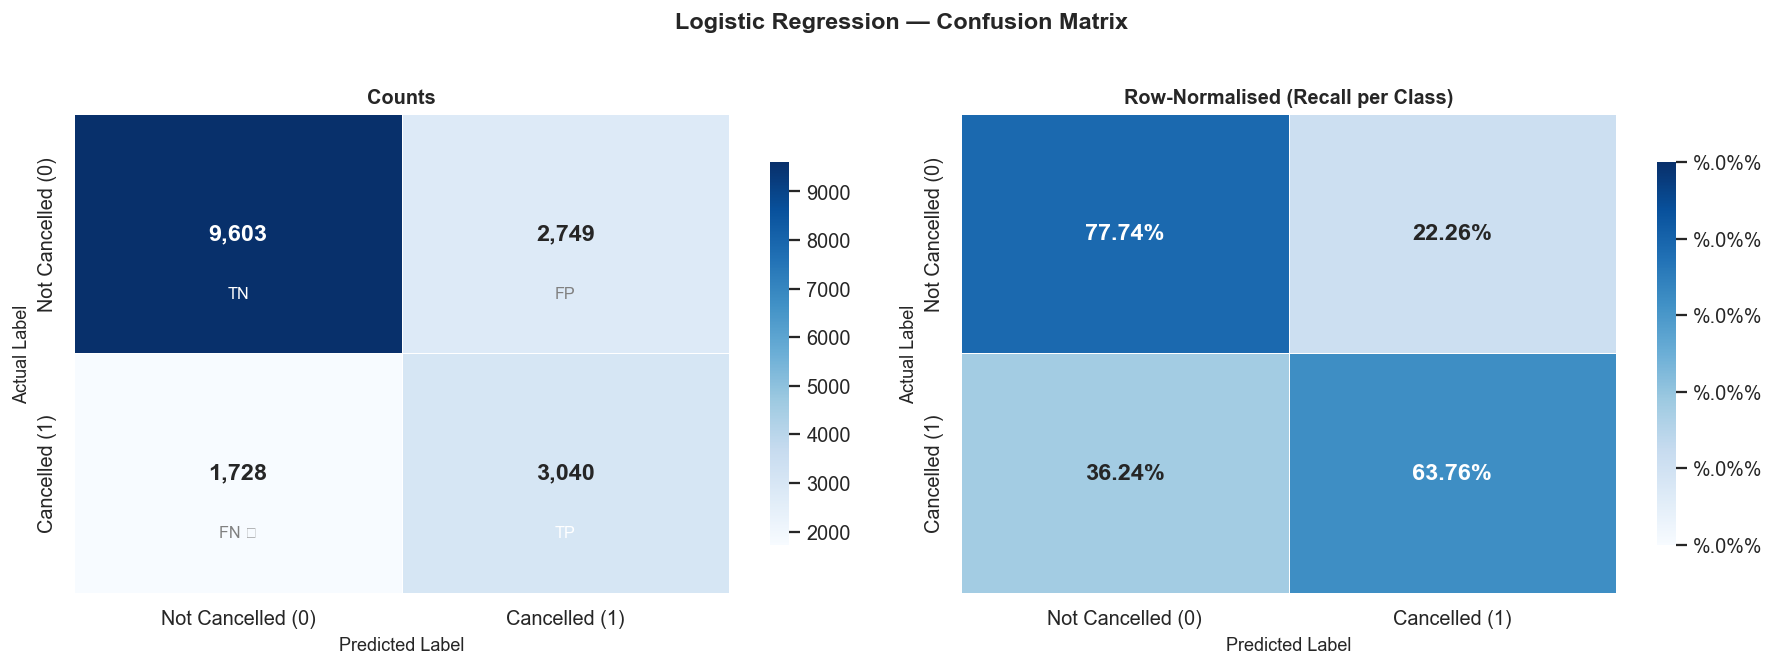

Saved -> visuals/lr_confusion_matrix.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Logistic Regression — Confusion Matrix",
             fontsize=13, fontweight="bold", y=1.02)

labels = ["Not Cancelled (0)", "Cancelled (1)"]

# ── Raw counts heatmap ───────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title("Counts", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Actual Label", fontsize=10)
axes[0].set_xlabel("Predicted Label", fontsize=10)

# Annotate cells
for (i, j), val in np.ndenumerate(cm):
    cell_label = {(0,0):"TN", (0,1):"FP", (1,0):"FN ⚠", (1,1):"TP"}
    axes[0].text(j + 0.5, i + 0.75, cell_label[(i,j)],
                 ha="center", va="center", fontsize=9,
                 color="white" if (i==j and val > 3000) else "gray")

# ── Normalised (row %) heatmap ───────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5, linecolor="white",
            vmin=0, vmax=1,
            cbar_kws={"shrink": 0.8, "format": "%.0%%"},
            annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title("Row-Normalised (Recall per Class)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Actual Label", fontsize=10)
axes[1].set_xlabel("Predicted Label", fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/lr_confusion_matrix.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/lr_confusion_matrix.png")


### ROC Curve

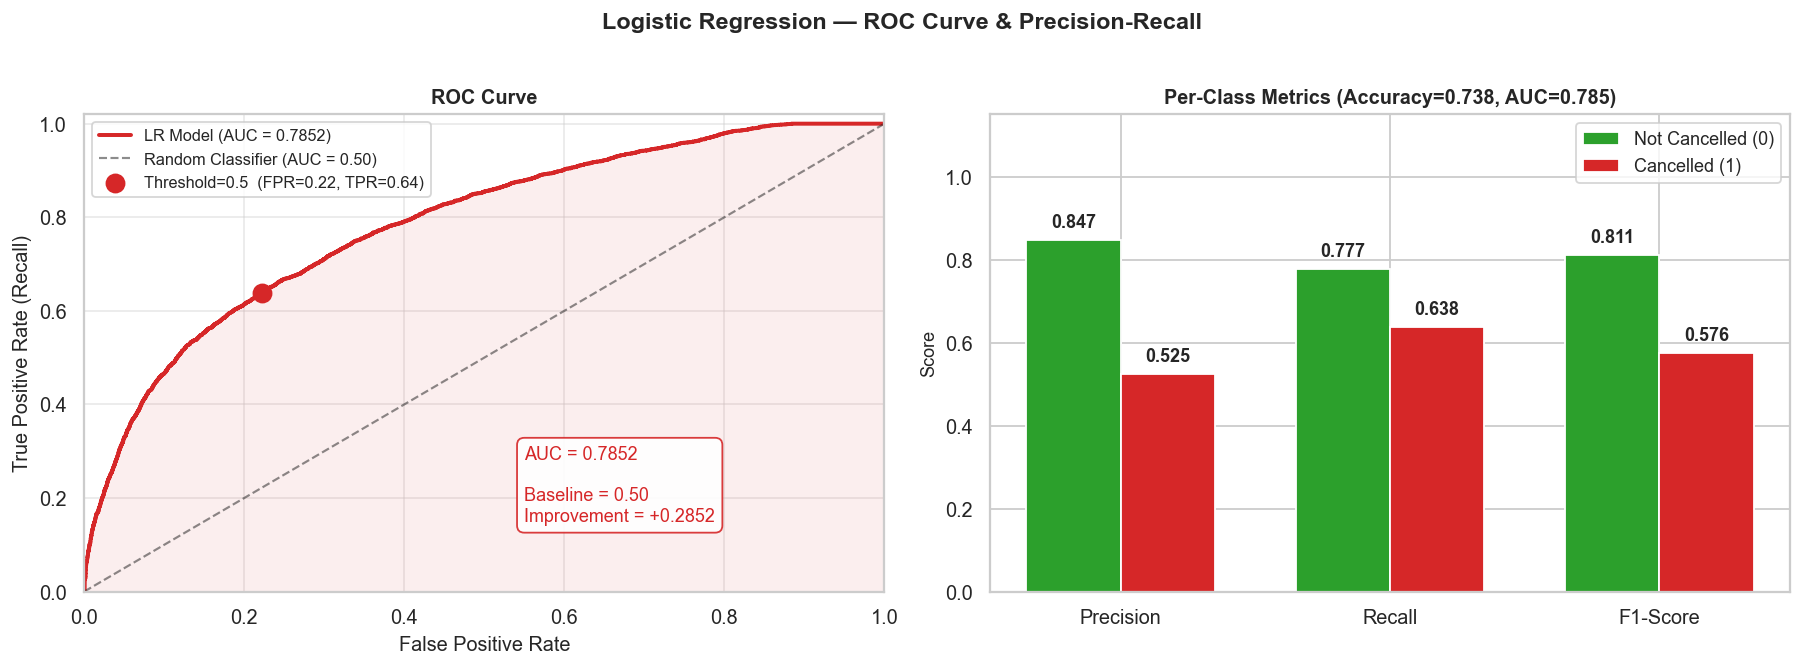

Saved -> visuals/lr_roc_curve.png


In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Logistic Regression — ROC Curve & Precision-Recall",
             fontsize=13, fontweight="bold", y=1.02)

# ── ROC Curve ────────────────────────────────────────────────────────────────
axes[0].plot(fpr, tpr, color="#d62728", lw=2.2,
             label=f"LR Model (AUC = {auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random Classifier (AUC = 0.50)")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#d62728")

# Mark default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
axes[0].scatter(fpr[default_idx], tpr[default_idx],
                color="#d62728", s=100, zorder=5,
                label=f"Threshold=0.5  (FPR={fpr[default_idx]:.2f}, TPR={tpr[default_idx]:.2f})")

axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# AUC annotation
axes[0].text(0.55, 0.15,
             f"AUC = {auc:.4f}\n\nBaseline = 0.50\nImprovement = +{auc-0.50:.4f}",
             fontsize=10, color="#d62728",
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                       edgecolor="#d62728", alpha=0.9))

# ── Metric summary bars ───────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_pred)

metric_names = ["Precision", "Recall", "F1-Score"]
class0_vals  = [prec[0], rec[0], f1[0]]
class1_vals  = [prec[1], rec[1], f1[1]]

x = np.arange(len(metric_names))
w = 0.35

bars0 = axes[1].bar(x - w/2, class0_vals, w, color="#2ca02c",
                    edgecolor="white", label="Not Cancelled (0)")
bars1 = axes[1].bar(x + w/2, class1_vals, w, color="#d62728",
                    edgecolor="white", label="Cancelled (1)")

axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names, fontsize=11)
axes[1].set_ylabel("Score", fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_title(f"Per-Class Metrics (Accuracy={acc:.3f}, AUC={auc:.3f})",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10)

for bars, vals in [(bars0, class0_vals), (bars1, class1_vals)]:
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{val:.3f}", ha="center", va="bottom",
                     fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/lr_roc_curve.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/lr_roc_curve.png")


In [8]:
import os

model_path = "../data/cleaned/model_lr.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model_lr, f)

print(f"✅ Model saved -> {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")


✅ Model saved -> ../data/cleaned/model_lr.pkl  (2.9 KB)


---
## 4 — Model Interpretation

### 4.1 Performance Summary

| Metric | Score | Interpretation |
|--------|-------|---------------|
| **Accuracy** | **73.85%** | Moderate — but misleading on imbalanced data |
| **ROC-AUC** | **0.7852** | Good separation — model ranks cancellations well |
| **Recall — Class 1 (Cancelled)** | **0.6375 (63.75%)** | Catches 6 in 10 cancellations |
| **Precision — Class 1** | **0.5247** | Of predicted cancels, ~52% are correct |
| **F1-Score — Class 1** | **0.5752** | Harmonic balance of precision/recall |
| **Recall — Class 0 (Not Cancelled)** | **0.7775** | Good — most stayers correctly identified |

---

### 4.2 What Is the Recall for Class 1 (Cancelled)?

**Recall for Cancelled (class 1) = 63.75%**

This means the model correctly identifies **3,040 out of 4,768 actual cancellations**
in the test set. The remaining **1,728 cancellations are missed** (False Negatives)
and predicted as "will stay."

The model predicts more conservatively than the true distribution — it predicts
**4,497 cancellations** vs the **4,768 actual** (under-predicting by ~5.7%).

---

### 4.3 Are We Catching Most Cancellations?

**Partially — but not sufficiently for a production system.**

A 63.75% recall means the model misses **1 in 3 cancellations**. In business terms,
this is significant but not catastrophic for a baseline model. The ROC-AUC of 0.7852
shows the model has genuine discriminative power — it correctly ranks a random
cancelled booking above a random non-cancelled booking 78.5% of the time.

The model performs better on class 0 (recall 77.75%) than class 1 (63.75%), which
is expected for a linear model on moderately non-linear hotel booking data. Despite
SMOTE balancing, Logistic Regression's linear decision boundary struggles to capture
the interaction effects between `lead_time`, `deposit_type`, `customer_type`, and
`market_segment` that drive cancellation risk.

---

### 4.4 What Does a False Negative Mean for the Hotel Business?

A **False Negative** = the model predicts a guest will arrive, but they cancel.

**Business consequences:**

| Consequence | Impact |
|------------|--------|
| **No overbooking buffer** | Room sits empty; full ADR loss (~£108/night average) |
| **No retention intervention** | Hotel never triggers re-confirmation campaign or upgrade offer |
| **No dynamic repricing** | Room isn't released to last-minute channel at discounted rate |
| **Operational overstaffing** | Housekeeping, F&B, and reception staffed for arrivals that don't come |

With **1,728 false negatives** in the test set (20% of data), extrapolated to the
full hotel operation this represents approximately:

```
1,728 × 5 (test is 20% of data) ≈ 8,640 missed cancellations per ~2 year period
8,640 × £108 avg ADR × 3.75 avg nights ≈ £3.5M in unrecovered revenue potential
```

Each false negative is an undefended revenue gap. Even partial reduction in false
negatives through a better model (e.g. Random Forest) would justify the modelling
investment.

---

### 4.5 Baseline vs Target

| Model | AUC | Recall (class 1) | Status |
|-------|-----|-----------------|--------|
| Random Classifier | 0.50 | ~27% | Baseline lower bound |
| **Logistic Regression** | **0.7852** | **63.75%** | ✅ This notebook |
| Random Forest (next) | TBD | TBD | 🔄 Target: >0.85 AUC |

Logistic Regression provides a solid, interpretable baseline. The **+0.2852 AUC
improvement over random** confirms the feature set carries genuine signal. The
next goal is a non-linear model (Random Forest) that can capture interaction effects
and push recall for class 1 above 75%.

> **Next:** `09_random_forest.ipynb` — Train and evaluate a Random Forest classifier;
> compare to this baseline; extract feature importance.
